In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import tqdm
import sys

sys.path.insert(0, '..')
from functions.IPAscoring import get_ranked_pairs
import functions.myfunctions as mf

In [ ]:
f2 = '../data/output/figures/'

In [3]:
vdj = pd.read_csv('../data/vdj_cleaned_subset_for_MI.csv', index_col = 0)
vdj = vdj.loc[vdj['Epitope'] != 'KLGGALQAK'] # because too big - takes forever
vdj = mf.prepare_data(vdj, col1 = 'cdr3a_IMGTgaps', col2='cdr3b_IMGTgaps', type = 'cdr3')
print(vdj.shape)

(9785, 37)


In [4]:
vdj = vdj.replace('https://www.10xgenomics.com/resources/application-notes/a-new-way-of-exploring-immunity-linking-highly-multiplexed-antigen-recognition-to-immune-repertoire-and-phenotype/#', '10xGenomics')
vdj = vdj.replace('https://github.com/antigenomics/vdjdb-db/issues/*', 'GitHubIssue', regex=True)
subject_id = mf.read_json_column(vdj, 'Meta', 'subject.id').tolist()
vdj['subject_id'] = subject_id
vdj['subject-PMID'] = vdj['Reference'].replace(pd.NA, 'unknown') + '_' + vdj['subject_id'].replace(pd.NA, 'unknown')
vdj = vdj.sort_values(by = ['Epitope', 'subject-PMID'])

In [5]:
correct_pairs = {}

for ep in vdj['Epitope'].unique():
    epdf = vdj.loc[vdj['Epitope'] == ep]
    correct_pairs[ep] = (epdf['CDR3-a'] + '::' + epdf['CDR3-b'] + '::' + epdf['subject-PMID']).tolist()

In [6]:
tulip_pred = []

for ep in vdj['Epitope'].unique():
    ep_res = pd.read_csv('../data/output/benchmarking/TULIP/' + ep + '.csv', index_col = 0)
    tulip_pred.append(ep_res)

In [7]:
tulip_pred = pd.concat(tulip_pred)
tulip_pred.head()

,CDR3a,CDR3b,peptide,score,rank
0,CAASEGSGSWQLIF,CASSAGLDAEQYF,ASNENMETM,-7.443481,1
1,CAASETSGSWQLIF,CASSRDLGRDTQYF,ASNENMETM,-6.528629,2
2,CAMREGNTGKLTF,CASRGGANTGQLYF,ASNENMETM,-0.018533,1387
3,CAMRVSSNYQLIW,CASRGGANTGQLYF,ASNENMETM,-0.018820,1382
4,CARGYGSSGNKLIF,CASRDWESSYEQYF,ASNENMETM,-1.190554,183


In [8]:
correct_pairs

{'ASNENMETM': ['CAASEGSGSWQLIF::CASSAGLDAEQYF::PMID:27717799_unknown',
  'CAASETSGSWQLIF::CASSRDLGRDTQYF::PMID:27717799_unknown',
  'CAMRANSGTYQRF::CASSGGGNTGQLYF::PMID:28636592_PDValx31BALpriM1',
  'CAMREGNTGKLTF::CASRGGANTGQLYF::PMID:28636592_PDValx31BALpriM1',
  'CAMRVSSNYQLIW::CASRGGANTGQLYF::PMID:28636592_PDValx31BALpriM1',
  'CARGYGSSGNKLIF::CASRDWESSYEQYF::PMID:28636592_PDValx31BALpriM1',
  'CAMRGGGGSNAKLTF::CASSGGANTGQLYF::PMID:28636592_PDValx31BALpriM2',
  'CAMRWNSGTYQRF::CASSGGANTGQLYF::PMID:28636592_PDValx31BALpriM2',
  'CAVRHNSGGSNAKLTF::CASSQARNTEVFF::PMID:28636592_PDValx31BALpriM2',
  'CAAPPTNAYKVIF::CASSQERGSAETLYF::PMID:28636592_PDValx31BALpriM3',
  'CAMRGPYGSSGNKLIF::CASKGGGNTGQLYF::PMID:28636592_PDValx31BALpriM3',
  'CALRNNNNAPRF::CGARDGGGEQYF::PMID:28636592_mouse_subject0004',
  'CAMERSGGNYKPTF::CAWSHTGGARNTLYF::PMID:28636592_mouse_subject0004',
  'CAMRDQGGRALIF::CASSGGANTGQLYF::PMID:28636592_mouse_subject0004',
  'CAMREALGEGGRALIF::CASSGGGNTGQLYF::PMID:28636592_mous

In [9]:
tulip_pred = tulip_pred.rename(columns={'CDR3a':'CDR3-a', 'CDR3b':'CDR3-b', 'peptide':'Epitope'})

In [10]:
tulip_pred

,CDR3-a,CDR3-b,Epitope,score,rank
0,CAASEGSGSWQLIF,CASSAGLDAEQYF,ASNENMETM,-7.443481,1
1,CAASETSGSWQLIF,CASSRDLGRDTQYF,ASNENMETM,-6.528629,2
2,CAMREGNTGKLTF,CASRGGANTGQLYF,ASNENMETM,-0.018533,1387
3,CAMRVSSNYQLIW,CASRGGANTGQLYF,ASNENMETM,-0.018820,1382
4,CARGYGSSGNKLIF,CASRDWESSYEQYF,ASNENMETM,-1.190554,183
...,...,...,...,...,...
38389,CAVNMLLGGGADGLTF,CASQDINTGELFF,YLQPRTFLL,-0.002488,29068
38390,CAVNMLLGGGADGLTF,CATTDLDSGELFF,YLQPRTFLL,-0.248287,15881
38391,CAVNMLLGGGADGLTF,CATQNLNTGELFF,YLQPRTFLL,-0.001249,34087
38392,CAVNMLLGGGADGLTF,CASSPTGGGNTGELFF,YLQPRTFLL,-0.055796,17481


In [11]:
assigned_pairs = {}

for ep in vdj['Epitope'].unique():
    print(ep)
    epdf_og = vdj.loc[vdj['Epitope'] == ep]
    epdf_og = epdf_og.sort_values(by = 'subject-PMID')
    epdf = tulip_pred.loc[tulip_pred['Epitope'] == ep]

    scores_mx = pd.DataFrame(np.nan,
                             index = pd.MultiIndex.from_arrays([epdf_og['subject-PMID'], epdf_og['CDR3-a'].astype(str),]),
                             columns = pd.MultiIndex.from_arrays([epdf_og['subject-PMID'], epdf_og['CDR3-b'].astype(str)]))
    alpha_seqs = [i[1] for i in scores_mx.index]
    beta_seqs = [i[1] for i in scores_mx.columns]

    assert scores_mx.shape[0] == scores_mx.shape[1] == epdf_og.shape[0]
    
    for i in tqdm.tqdm(range(epdf.shape[0])):
        row = epdf.iloc[i]
        a, b, s = row['CDR3-a'], row['CDR3-b'], row['score'].astype(float)
        scores_mx.loc[(slice(None), a), (slice(None), b)] = s
    
    scores_mx = -1*scores_mx.values

    IDs = epdf_og['subject-PMID'].tolist()
    assert len(IDs) == scores_mx.shape[0] == scores_mx.shape[1]

    mask = np.array([[int(IDs[i] != IDs[j]) for j in range(len(IDs))] for i in range(len(IDs))], dtype=bool)
    scores_mx[mask] = np.nan

    ranked_pairs = get_ranked_pairs(scores_mx, [IDs,IDs])

    assigned_pairs[ep] = [alpha_seqs[a]+'::'+beta_seqs[b]+'::'+ind for a,b,ind in ranked_pairs]

ASNENMETM


100%|██████████| 1599/1599 [00:01<00:00, 975.43it/s] 
/home/marti/gitscripts/AB-interactions/pairing_prediction_other_software/../functions/IPAscoring.py:156: UserWarning: Tie detected! Picking a random pair
  warn('Tie detected! Picking a random pair')


ATDALMTGF


100%|██████████| 10989/10989 [00:08<00:00, 1317.46it/s]
/home/marti/gitscripts/AB-interactions/pairing_prediction_other_software/../functions/IPAscoring.py:156: UserWarning: Tie detected! Picking a random pair
  warn('Tie detected! Picking a random pair')


AVFDRKSDAK


...

100%|██████████| 1324/1324 [00:00<00:00, 1462.27it/s]
/home/marti/gitscripts/AB-interactions/pairing_prediction_other_software/../functions/IPAscoring.py:156: UserWarning: Tie detected! Picking a random pair
  warn('Tie detected! Picking a random pair')


TTDPSFLGRY


100%|██████████| 53592/53592 [00:37<00:00, 1430.81it/s]
/home/marti/gitscripts/AB-interactions/pairing_prediction_other_software/../functions/IPAscoring.py:156: UserWarning: Tie detected! Picking a random pair
  warn('Tie detected! Picking a random pair')


YLQPRTFLL


100%|██████████| 38394/38394 [00:26<00:00, 1466.77it/s]
/home/marti/gitscripts/AB-interactions/pairing_prediction_other_software/../functions/IPAscoring.py:156: UserWarning: Tie detected! Picking a random pair
  warn('Tie detected! Picking a random pair')


In [12]:
tulip_results = pd.DataFrame()
for ep in vdj['Epitope'].unique():
    correct = correct_pairs[ep]
    predicted = assigned_pairs[ep]
    correctly_predicted = [p in correct for p in predicted]
    tot = len(correct)
    print(ep, 'Precision: ', sum(correctly_predicted) / tot)
    tulip_results.loc[ep, 'prop_correct'] = sum(correctly_predicted) / tot

ASNENMETM Precision:  0.3034825870646766
ATDALMTGF Precision:  0.016
AVFDRKSDAK Precision:  0.011771630370806356
CINGVCWTV Precision:  0.035398230088495575
ELAGIGILTV Precision:  0.031578947368421054
GILGFVFTL Precision:  0.07761351636747624
GLCTLVAML Precision:  0.1246376811594203
HGIRNASFI Precision:  0.04526748971193416
IVTDFSVIK Precision:  0.21022727272727273
KSKRTPMGF Precision:  0.02912621359223301
LLWNGPMAV Precision:  0.01276595744680851
LSLRNPILV Precision:  0.15748031496062992
LTDEMIAQY Precision:  0.016129032258064516
NLVPMVATV Precision:  0.2184873949579832
RAKFKQLL Precision:  0.13583333333333333
RLRAEAQVK Precision:  0.021844660194174758
SPRWYFYYL Precision:  0.03428571428571429
SSLENFRAYV Precision:  0.06285714285714286
SSPPMFRV Precision:  0.3082706766917293
SSYRRPVGI Precision:  0.23163841807909605
TTDPSFLGRY Precision:  0.0
YLQPRTFLL Precision:  0.03303303303303303


In [13]:
tulip_results.to_csv('../data/output/benchmarking/TULIP_results.csv')

In [14]:
eps = sorted(vdj['Epitope'].unique())

ASNENMETM 0.3034825870646766 0.41492537313432826
ATDALMTGF 0.016 0.02912
AVFDRKSDAK 0.011771630370806356 0.013125714285714242
CINGVCWTV 0.035398230088495575 0.04150442477876101
ELAGIGILTV 0.031578947368421054 0.03576315789473678
GILGFVFTL 0.07761351636747624 0.13958857142857142
GLCTLVAML 0.1246376811594203 0.2655942028985507
HGIRNASFI 0.04526748971193416 0.11600823045267486
IVTDFSVIK 0.21022727272727273 0.22598011363636356
KSKRTPMGF 0.02912621359223301 0.04669902912621355
LLWNGPMAV 0.01276595744680851 0.021659574468085054
LSLRNPILV 0.15748031496062992 0.28992125984251965
LTDEMIAQY 0.016129032258064516 0.04733870967741931
NLVPMVATV 0.2184873949579832 0.2525210084033613
RAKFKQLL 0.13583333333333333 0.11711714285714282
RLRAEAQVK 0.021844660194174758 0.014611650485436847
SPRWYFYYL 0.03428571428571429 0.0647428571428571
SSLENFRAYV 0.06285714285714286 0.15254285714285712
SSPPMFRV 0.3082706766917293 0.450375939849624
SSYRRPVGI 0.23163841807909605 0.27954802259887
TTDPSFLGRY 0.0 0.009132231404

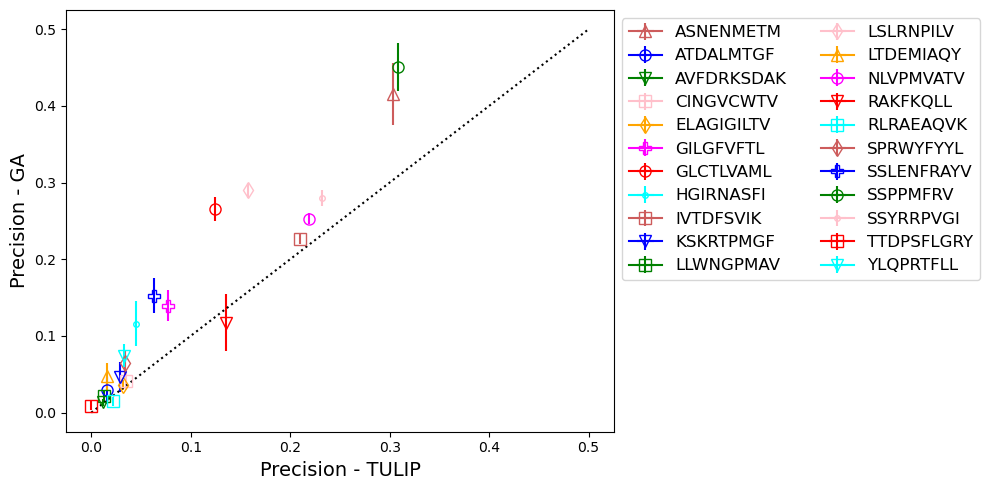

In [15]:
ga = pd.read_csv('../GA_results_TPR.csv', index_col=0)
ga['Epitope'] = [x.split('_')[0] for x in ga['epitope']]

f, ax = plt.subplots(figsize = (10,5))
symbols = ['^', 'o', 'v', 's', 'd', 'P','o','.','s','v', 's', 'd','^', 'o', 'v', 's', 'd', 'P','o','.','s','v']
colors = ['indianred','blue','g','pink','orange','fuchsia','red','cyan',
          'indianred','blue','g','pink','orange','fuchsia','red','cyan',
          'indianred','blue','g','pink', 'red','cyan']

for i, ep in enumerate(eps):
    y = np.mean(ga.loc[ga['Epitope'] == ep]['prop_correct'])
    y_err = np.std(ga.loc[ga['Epitope'] == ep]['prop_correct'])
    x = tulip_results.loc[ep]['prop_correct']
    print(ep, x,y)

    ax.errorbar(x, y, label = ep, yerr = y_err, xerr = 0, 
                marker = symbols[i], ms = 8, markerfacecolor='None', color=colors[i])

ax.plot([0,.5],[0,.5], c='k', ls=':')
ax.set_xlabel('Precision - TULIP', fontsize=14)
ax.set_ylabel('Precision - GA', fontsize=14)
plt.legend(bbox_to_anchor = [1,1], ncols=2, fontsize=12)
plt.tight_layout()
plt.savefig(f2 + 'TULIP_vs_GA.pdf', bbox_inches = 'tight')
plt.show()

ASNENMETM 0.3034825870646766 0.3925373134328358
ATDALMTGF 0.016 0.018400000000000003
AVFDRKSDAK 0.011771630370806356 0.01122857142857139
CINGVCWTV 0.035398230088495575 0.03982300884955749
ELAGIGILTV 0.031578947368421054 0.03736842105263151
GILGFVFTL 0.07761351636747624 0.10994285714285709
GLCTLVAML 0.1246376811594203 0.1953623188405797
HGIRNASFI 0.04526748971193416 0.12386831275720163
IVTDFSVIK 0.21022727272727273 0.2380681818181818
KSKRTPMGF 0.02912621359223301 0.02330097087378638
LLWNGPMAV 0.01276595744680851 0.02042553191489356
LSLRNPILV 0.15748031496062992 0.18503937007874016
LTDEMIAQY 0.016129032258064516 0.019354838709677358
NLVPMVATV 0.2184873949579832 0.23837535014005598
RAKFKQLL 0.13583333333333333 0.13505714285714282
RLRAEAQVK 0.021844660194174758 0.013592233009708668
SPRWYFYYL 0.03428571428571429 0.06571428571428567
SSLENFRAYV 0.06285714285714286 0.09514285714285711
SSPPMFRV 0.3082706766917293 0.45789473684210513
SSYRRPVGI 0.23163841807909605 0.25536723163841807
TTDPSFLGRY 0

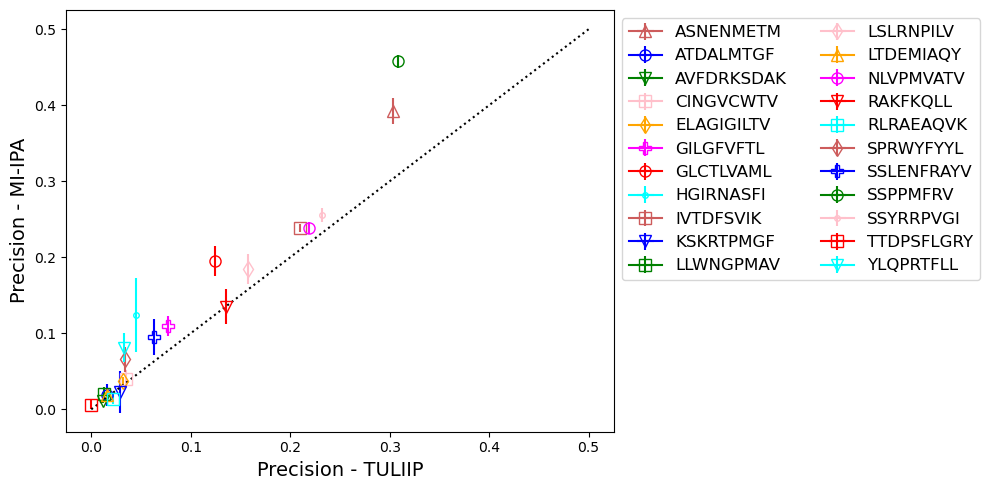

In [16]:
miipa = pd.read_csv('../MI-IPA_results_TPR.csv', index_col=0)
miipa = miipa.loc[miipa['L'] == 0.6]
miipa['Epitope'] = [x.split('_')[0] for x in miipa['epitope']]

f, ax = plt.subplots(figsize = (10,5))

for i, ep in enumerate(eps):
    y = np.mean(miipa.loc[miipa['Epitope'] == ep]['final_test_prop'])
    y_err = np.std(miipa.loc[miipa['Epitope'] == ep]['final_test_prop'])
    x = tulip_results.loc[ep]['prop_correct']
    print(ep, x,y)

    ax.errorbar(x, y, label = ep, yerr = y_err, xerr = 0, 
                marker = symbols[i], ms = 8, markerfacecolor='None', color=colors[i])

ax.plot([0,.5],[0,.5], c='k', ls=':')
ax.set_xlabel('Precision - TULIIP', fontsize=14)
ax.set_ylabel('Precision - MI-IPA', fontsize=14)
plt.legend(bbox_to_anchor = [1,1], ncols=2, fontsize=12)
plt.tight_layout()
plt.savefig(f2 + 'TULIP_vs_MIIPA.pdf', bbox_inches = 'tight')
plt.show()

ASNENMETM 0.3034825870646766 0.3980099502487562
ATDALMTGF 0.016 0.012
AVFDRKSDAK 0.011771630370806356 0.01599999999999995
CINGVCWTV 0.035398230088495575 0.024336283185840652
ELAGIGILTV 0.031578947368421054 0.031578947368421
GILGFVFTL 0.07761351636747624 0.11834285714285711
GLCTLVAML 0.1246376811594203 0.2434782608695652
HGIRNASFI 0.04526748971193416 0.16213991769547323
IVTDFSVIK 0.21022727272727273 0.2428977272727272
KSKRTPMGF 0.02912621359223301 0.06504854368932031
LLWNGPMAV 0.01276595744680851 0.03234042553191484
LSLRNPILV 0.15748031496062992 0.2677165354330709
LTDEMIAQY 0.016129032258064516 0.05241935483870963
NLVPMVATV 0.2184873949579832 0.2577030812324929
RAKFKQLL 0.13583333333333333 0.12322857142857138
RLRAEAQVK 0.021844660194174758 0.01407766990291256
SPRWYFYYL 0.03428571428571429 0.0457142857142857
SSLENFRAYV 0.06285714285714286 0.14885714285714283
SSPPMFRV 0.3082706766917293 0.4511278195488721
SSYRRPVGI 0.23163841807909605 0.2655367231638418
TTDPSFLGRY 0.0 0.008264462809917302

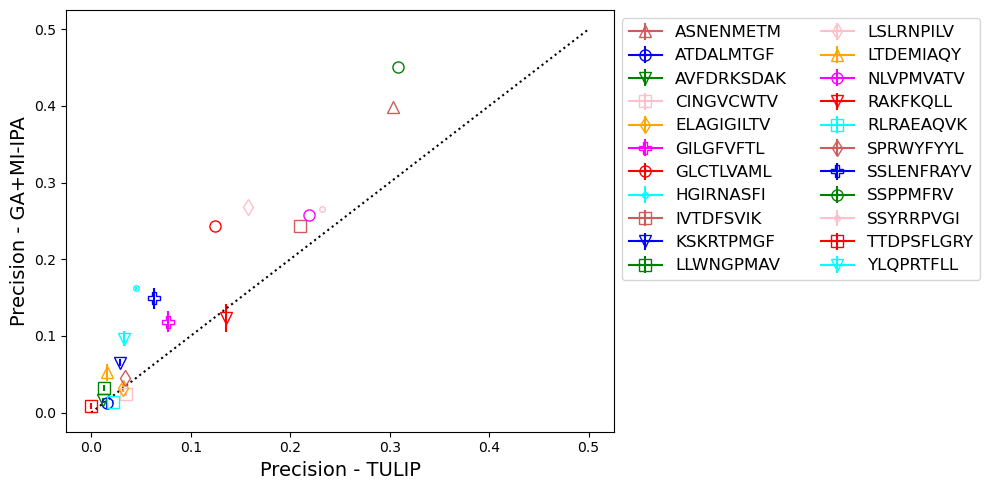

In [17]:
gami = pd.read_csv('../GA+MI-IPA_results_TPR.csv', index_col=0)
gami = gami.loc[gami['L'] == 0.6]
gami['Epitope'] = [x.split('_')[0] for x in gami['epitope']]

f, ax = plt.subplots(figsize = (10,5))

for i, ep in enumerate(eps):
    y = np.mean(gami.loc[gami['Epitope'] == ep]['final_test_prop'])
    y_err = np.std(gami.loc[gami['Epitope'] == ep]['final_test_prop'])
    x = tulip_results.loc[ep]['prop_correct']
    print(ep, x,y)

    ax.errorbar(x, y, label = ep, yerr = y_err, xerr = 0, 
                marker = symbols[i], ms = 8, markerfacecolor='None', color=colors[i])

ax.plot([0,.5],[0,.5], c='k', ls=':')
ax.set_xlabel('Precision - TULIP', fontsize=14)
ax.set_ylabel('Precision - GA+MI-IPA', fontsize=14)
plt.legend(bbox_to_anchor = [1,1], ncols=2, fontsize=12)
plt.tight_layout()
plt.savefig(f2 + 'TULIP_vs_GAMI.pdf', bbox_inches = 'tight')
plt.show()

ASNENMETM 0.3034825870646766 0.22487562189054722
ATDALMTGF 0.016 0.010400000000000001
AVFDRKSDAK 0.011771630370806356 0.010571428571428532
CINGVCWTV 0.035398230088495575 0.030530973451327374
ELAGIGILTV 0.031578947368421054 0.03894736842105258
GILGFVFTL 0.07761351636747624 0.09731428571428567
GLCTLVAML 0.1246376811594203 0.1197101449275362
HGIRNASFI 0.04526748971193416 0.06790123456790118
IVTDFSVIK 0.21022727272727273 0.2201704545454545
KSKRTPMGF 0.02912621359223301 0.017475728155339758
LLWNGPMAV 0.01276595744680851 0.01063829787234038
LSLRNPILV 0.15748031496062992 0.12362204724409445
LTDEMIAQY 0.016129032258064516 0.02499999999999996
NLVPMVATV 0.2184873949579832 0.17478991596638654
RAKFKQLL 0.13583333333333333 0.08814285714285709
RLRAEAQVK 0.021844660194174758 0.01140776699029121
SPRWYFYYL 0.03428571428571429 0.06399999999999997
SSLENFRAYV 0.06285714285714286 0.06542857142857139
SSPPMFRV 0.3082706766917293 0.24511278195488714
SSYRRPVGI 0.23163841807909605 0.2175141242937853
TTDPSFLGRY 

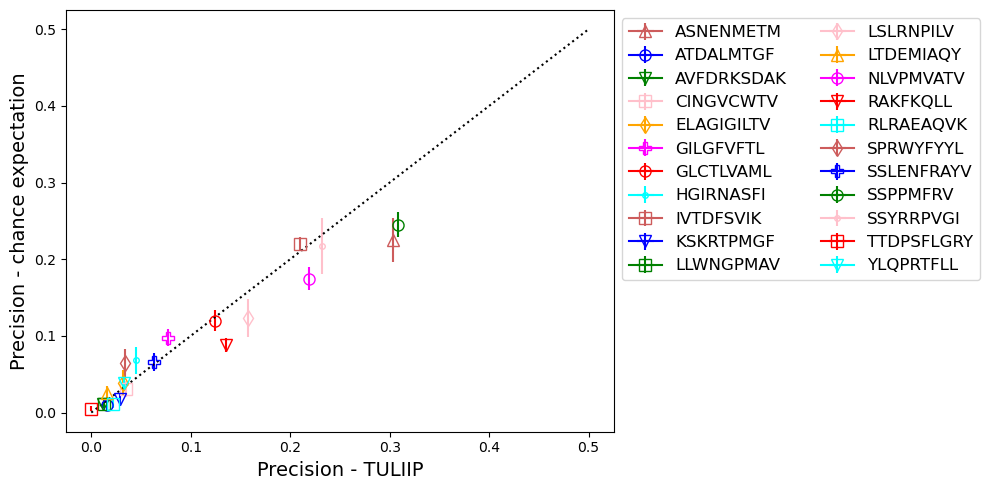

In [18]:
miipa = pd.read_csv('../MI-IPA_results_TPR.csv', index_col=0)
miipa = miipa.loc[miipa['L'] == 1]
miipa['Epitope'] = [x.split('_')[0] for x in miipa['epitope']]

f, ax = plt.subplots(figsize = (10,5))

for i, ep in enumerate(eps):
    y = np.mean(miipa.loc[miipa['Epitope'] == ep]['final_test_prop'])
    y_err = np.std(miipa.loc[miipa['Epitope'] == ep]['final_test_prop'])
    x = tulip_results.loc[ep]['prop_correct']
    print(ep, x,y)

    ax.errorbar(x, y, label = ep, yerr = y_err, xerr = 0, 
                marker = symbols[i], ms = 8, markerfacecolor='None', color=colors[i])

ax.plot([0,.5],[0,.5], c='k', ls=':')
ax.set_xlabel('Precision - TULIIP', fontsize=14)
ax.set_ylabel('Precision - chance expectation', fontsize=14)
plt.legend(bbox_to_anchor = [1,1], ncols=2, fontsize=12)
plt.tight_layout()
plt.savefig(f2 + 'TULIP_vs_MIIPA_L1.pdf', bbox_inches = 'tight')
plt.show()